# PayGuard — Real-Time Payment Fraud Detection

**Machine Learning**

This notebook reconstructs the ML solution for PayGuard's real-time fraud detection problem,
covering all three phases: Problem Framing, Data Lifecycle, and Model Serving prep.

Dataset: [ULB Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
— 284,807 transactions, 492 confirmed frauds (~0.17%).


## 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve,       # returns precision/recall at every possible threshold -> lets us pick a threshold, not just accept 0.5
    average_precision_score,      # this IS the PR-AUC number (area under the precision-recall curve)
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pd.set_option('display.max_columns', None)  # show all 31 columns when printing a DataFrame, otherwise pandas truncates the middle ones

## 1. Load Data

Loading the raw CSV first, before any cleaning, so we can inspect it in its original state.

In [ ]:
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis (EDA)

### 2.1 Missing values
Checking for nulls first — a model can't train on missing data without an explicit strategy
(imputation, dropping), so we need to know if this is even a problem here.

In [3]:
df.isnull().sum()  # per-column null count -- if this is all zeros, no missing-data strategy is needed

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### 2.2 Duplicate rows
Exact duplicate rows are a risk: if a duplicate ends up in both train and test after splitting,
the model gets tested on something it already memorized, which inflates our metrics artificially.

In [4]:
n_duplicates = df.duplicated().sum()  # .duplicated() flags rows that are an exact repeat of an earlier row
print("Duplicate rows:", n_duplicates)

Duplicate rows: 1081


### 2.3 Class distribution (the core challenge of this project)
This is the most important check in the whole notebook. If fraud is rare, accuracy becomes a
misleading metric (a model predicting "not fraud" always would still score >99%).

In [5]:
print(df['Class'].value_counts())
print()
print(df['Class'].value_counts(normalize=True) * 100)  # normalize=True converts counts to proportions (%) instead of raw counts

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### 2.4 Transaction amount by class
Looking at how `Amount` differs between fraud and non-fraud. This also feeds directly into the
cost-benefit analysis later (we use the average fraud amount as our "cost of a missed fraud").

In [6]:
df.groupby('Class')['Amount'].describe()  # groupby splits the data into the two Class groups, describe() gives mean/std/min/max/quartiles for each

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## 3. Data Cleaning

Dropping the exact duplicate rows found above. We do this **before** splitting into train/test,
so no duplicate can leak across the split.

In [7]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print(df['Class'].value_counts())

Shape after removing duplicates: (283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


## 4. Train/Test Split — Time-Based, Not Random

**Why not a random split?** In production, PayGuard always trains on past transactions and scores
future ones. A random shuffle would let the model "see the future" during training (rows from
later in time end up in the training set), which makes the evaluation overly optimistic. Sorting
by `Time` and taking the last 20% as test simulates the real deployment scenario honestly.

In [10]:
df = df.sort_values('Time').reset_index(drop=True)  # sort chronologically; reset_index so row numbers are clean 0..N after sorting

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]   # earlier 80% of transactions (by time) -> training data
test_df = df.iloc[split_idx:]    # later 20% of transactions (by time)   -> test data, simulates "the future"

feature_cols = [c for c in df.columns if c not in ['Class']]  # every column except the label is a feature
X_train, y_train = train_df[feature_cols], train_df['Class']
X_test, y_test = test_df[feature_cols], test_df['Class']

print(f"Train: {X_train.shape}, frauds: {y_train.sum()}")
print(f"Test:  {X_test.shape}, frauds: {y_test.sum()}")


Train: (226980, 30), frauds: 399
Test:  (56746, 30), frauds: 74


## 5. Model Training

### Handling the imbalance
We use `class_weight='balanced'` on both models. This tells the model to internally penalize
mistakes on the minority class (fraud) more heavily than mistakes on the majority class, which
compensates for fraud being ~0.17% of the data — without needing to physically duplicate/generate
synthetic fraud rows (e.g. SMOTE, which requires `imbalanced-learn` — not available in this
environment, see README for details).

We train two candidate models and compare them on **PR-AUC**, not accuracy (see section 2.3 for why).

In [11]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # up-weights the rare fraud class during training
        random_state=42            # fixes randomness so results are reproducible on re-run
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=200,          # number of decision trees in the forest
        max_depth=12,              # caps tree depth to reduce overfitting risk
        class_weight='balanced',
        n_jobs=-1,                 # use all CPU cores to speed up training
        random_state=42
    ),
}

results = {}
for name, model in models.items():
    print(f"=== Training {name} ===")
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (fraud) for each test row

    pr_auc = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}\n")

    results[name] = {"model": model, "proba": proba, "pr_auc": pr_auc, "roc_auc": roc_auc}


=== Training logistic_regression ===


c:\Users\najaf\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


PR-AUC: 0.7359 | ROC-AUC: 0.9851

=== Training random_forest ===
PR-AUC: 0.8048 | ROC-AUC: 0.9812



## 6. Model Selection

Picking the winner by **PR-AUC** (the metric that matters for imbalanced problems), not accuracy.

In [12]:
best_name = max(results, key=lambda k: results[k]['pr_auc'])  # key= tells max() to compare by pr_auc, not alphabetically
best = results[best_name]
print(f"Best model: {best_name} (PR-AUC={best['pr_auc']:.4f})")

Best model: random_forest (PR-AUC=0.8048)


## 7. Cost-Based Threshold Selection

A false negative (missed fraud) and a false positive (blocked real customer) do not cost the same,
so the default 0.5 probability cutoff is arbitrary and not business-aligned.

**Assumed costs (illustrative — document your own reasoning here for the presentation):**
- Cost of a False Negative ≈ **$122** (the average fraud transaction amount from section 2.4 — this is what PayGuard loses if the fraud goes through)
- Cost of a False Positive ≈ **$5** (estimated friction/support cost of wrongly blocking a real customer)

We scan every possible threshold from the precision-recall curve and pick the one that minimizes
total estimated dollar cost across the test set.

In [13]:
COST_FN = 122   # $ lost per missed fraud (false negative)
COST_FP = 5     # $ cost per wrongly-blocked real customer (false positive)

# precision_recall_curve returns arrays of precision/recall for a sweep of thresholds;
# thresholds array is 1 shorter than precisions/recalls, so we drop the last precision/recall value to align lengths
precisions, recalls, thresholds = precision_recall_curve(y_test, best['proba'])

best_threshold = 0.5
best_cost = float('inf')
for p, r, t in zip(precisions[:-1], recalls[:-1], thresholds):
    preds = (best['proba'] >= t).astype(int)  # apply this candidate threshold to get 0/1 predictions
    fp = ((preds == 1) & (y_test.values == 0)).sum()  # predicted fraud, actually legit
    fn = ((preds == 0) & (y_test.values == 1)).sum()  # predicted legit, actually fraud
    total_cost = fp * COST_FP + fn * COST_FN
    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = t

print(f"Cost-optimal threshold: {best_threshold:.4f}")
print(f"Estimated total cost at this threshold: ${best_cost:.2f}")

Cost-optimal threshold: 0.1117
Estimated total cost at this threshold: $1914.00


### Visualizing the Precision-Recall trade-off
Plotting the curve with the chosen threshold marked, so it's easy to show in the presentation
*why* this threshold was picked over the default.

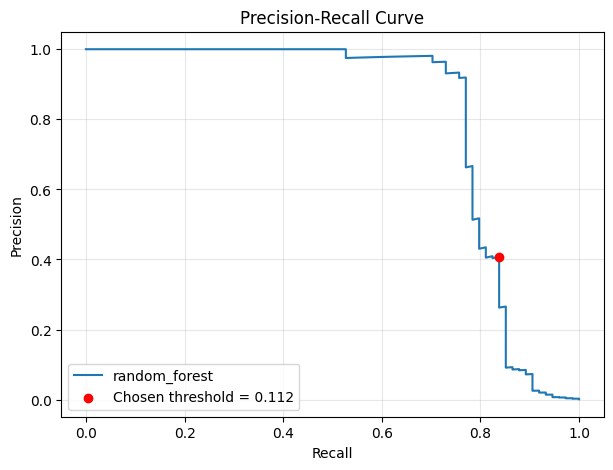

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label=f"{best_name}")
# find the point on the curve closest to our chosen threshold, just to mark it visually
closest_idx = (abs(thresholds - best_threshold)).argmin()
plt.scatter(recalls[closest_idx], precisions[closest_idx], color='red', zorder=5,
            label=f"Chosen threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Final Evaluation at the Chosen Threshold

This is the report you'd actually present — **not** the raw accuracy number, since it's misleading
for this imbalanced problem (see section 2.3).

In [15]:
final_preds = (best['proba'] >= best_threshold).astype(int)

print("Classification report:")
print(classification_report(y_test, final_preds, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test, final_preds))
# Reading this matrix: rows = actual class, columns = predicted class
# [ [True Negatives,  False Positives],
#   [False Negatives, True Positives] ]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9984    0.9991     56672
           1     0.4079    0.8378    0.5487        74

    accuracy                         0.9982     56746
   macro avg     0.7038    0.9181    0.7739     56746
weighted avg     0.9990    0.9982    0.9985     56746

Confusion matrix:
[[56582    90]
 [   12    62]]


## 9. Save Model Artifacts

Saving the trained model and its metadata (threshold + feature order) so the serving API
(`api/main.py`) can load them without retraining.

In [16]:
joblib.dump(best['model'], 'model.joblib')  # serializes the trained sklearn model object to disk
joblib.dump(
    {'threshold': best_threshold, 'feature_cols': feature_cols, 'model_name': best_name},
    'model_meta.joblib'
)
print("Saved model.joblib and model_meta.joblib")

Saved model.joblib and model_meta.joblib


## 10. Summary

- **Problem framing**: rare-event binary classification, evaluated with PR-AUC/precision/recall instead of accuracy.
- **Best model**: selected by PR-AUC (see section 6).
- **Threshold**: chosen by minimizing estimated business cost (FP vs FN), not the default 0.5.
- **Next steps** (see project README for full detail): serve via FastAPI (`api/main.py`), log every prediction, and monitor for data/model drift over time as fraud patterns evolve.
